In [1]:
import itertools
import sys
import uproot
import awkward as ak
import numpy as np
import pandas as pd
from coffea import nanoevents
from coffea.analysis_tools import Weights
import vector
import fastjet
from rich import print
from rich.progress import track
import math
import matplotlib.pyplot as plt
import matplotlib
import mplhep as hep
import hist
from hist import Hist
from scipy.linalg import eigvalsh
import correctionlib

import lhapdf
import pythia8
import parton

In [2]:
sys.path.insert(0, "../../workflows/")

In [3]:
matplotlib.rcParams.update({"figure.max_open_warning": 0})
hep.style.use(hep.style.CMS)

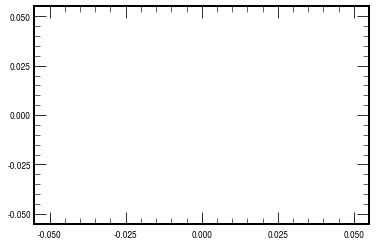

In [4]:
plt.plot()
hep.style.use(hep.style.CMS)

In [5]:
np.set_printoptions(precision=2)

In [6]:
vector.register_awkward()

In [8]:
xrd_path = "root://cmseos.fnal.gov//store/group/lpcsuep/"

file_qcd = nanoevents.NanoEventsFactory.from_root(
    f"{xrd_path}/Muon_counting_search/SUEPNano_UL18_Nov2024_merged/QCD_Pt-300To470_MuEnrichedPt5_TuneCP5_13TeV-pythia8/merged_0.root",
    schemaclass=nanoevents.NanoAODSchema,
)
events_qcd = file_qcd.events()

mS = "1000"
T = "8"
mPhi = "8"
signal_name = f"GluGluToSUEP_T{T}p00_TuneCP5_13TeV_pythia8_split/SUEP_mS{mS}.000_mPhi{mPhi}.000_T{T}.000_modehadronic"
file_signal = nanoevents.NanoEventsFactory.from_root(
    f"{xrd_path}/Muon_counting_search/SUEPNano_UL18_May2025_merged/{signal_name}/merged_0.root",
    schemaclass=nanoevents.NanoAODSchema,
)
events_signal = file_signal.events()

In [9]:
print("n_events_qcd", len(events_qcd))
print("n_events_signal", len(events_signal))

n_events_qcd 86053

n_events_signal 16688

In [10]:
events_qcd = events_qcd[
    events_qcd.HLT.TripleMu_12_10_5
    | events_qcd.HLT.TripleMu_10_5_5_DZ
    | events_qcd.HLT.TripleMu_5_3_3_Mass3p8_DZ
]

events_signal = events_signal[
    events_signal.HLT.TripleMu_12_10_5
    | events_signal.HLT.TripleMu_10_5_5_DZ
    | events_signal.HLT.TripleMu_5_3_3_Mass3p8_DZ
]

In [11]:
muons_qcd = events_qcd.Muon[
    (events_qcd.Muon.mediumId)
    & (events_qcd.Muon.pt > 3)
    & (abs(events_qcd.Muon.eta) < 2.4)
    & (abs(events_qcd.Muon.dz) < 0.2)
]

muons_signal = events_signal.Muon[
    (events_signal.Muon.mediumId)
    & (events_signal.Muon.pt > 3)
    & (abs(events_signal.Muon.eta) < 2.4)
    & (abs(events_signal.Muon.dz) < 0.2)
]

In [12]:
enough_muons_qcd = ak.num(muons_qcd) >= 3
events_qcd = events_qcd[enough_muons_qcd]
muons_qcd = muons_qcd[enough_muons_qcd]

enough_muons_signal = ak.num(muons_signal) >= 3
events_signal = events_signal[enough_muons_signal]
muons_signal = muons_signal[enough_muons_signal]

In [13]:
muons1_qcd = muons_qcd[muons_qcd.charge == 1]
muons2_qcd = muons_qcd[muons_qcd.charge == -1]
muons1_idx_qcd = ak.local_index(muons_qcd)[muons_qcd.charge == 1]
muons2_idx_qcd = ak.local_index(muons_qcd)[muons_qcd.charge == -1]

muons1_signal = muons_signal[muons_signal.charge == 1]
muons2_signal = muons_signal[muons_signal.charge == -1]
muons1_idx_signal = ak.local_index(muons_signal)[muons_signal.charge == 1]
muons2_idx_signal = ak.local_index(muons_signal)[muons_signal.charge == -1]

In [14]:
enough_muons_qcd = (ak.num(muons1_qcd) > 0) & (ak.num(muons2_qcd) > 0)

enough_muons_signal = (ak.num(muons1_signal) > 0) & (ak.num(muons2_signal) > 0)

In [15]:
muons1_qcd = muons1_qcd[enough_muons_qcd]
muons2_qcd = muons2_qcd[enough_muons_qcd]
muons1_idx_qcd = muons1_idx_qcd[enough_muons_qcd]
muons2_idx_qcd = muons2_idx_qcd[enough_muons_qcd]

muons1_signal = muons1_signal[enough_muons_signal]
muons2_signal = muons2_signal[enough_muons_signal]
muons1_idx_signal = muons1_idx_signal[enough_muons_signal]
muons2_idx_signal = muons2_idx_signal[enough_muons_signal]

In [16]:
muons_qcd = muons_qcd[enough_muons_qcd]
events_qcd = events_qcd[enough_muons_qcd]

muons_signal = muons_signal[enough_muons_signal]
events_signal = events_signal[enough_muons_signal]

In [17]:
muon_pairs_qcd = ak.unzip(ak.cartesian([muons1_qcd, muons2_qcd], nested=False))
muon_pairs_idx_qcd = ak.unzip(
    ak.cartesian([muons1_idx_qcd, muons2_idx_qcd], nested=False)
)
muon_pairs_0_qcd = muon_pairs_qcd[0]
muon_pairs_1_qcd = muon_pairs_qcd[1]
muon_pairs_0_idx_qcd = muon_pairs_idx_qcd[0]
muon_pairs_1_idx_qcd = muon_pairs_idx_qcd[1]
found_pairs_0_qcd = ak.copy(muon_pairs_0_qcd)[ak.local_index(muon_pairs_0_qcd) < 0]
found_pairs_1_qcd = ak.copy(muon_pairs_1_qcd)[ak.local_index(muon_pairs_1_qcd) < 0]
found_pairs_0_idx_qcd = ak.copy(muon_pairs_0_idx_qcd)[
    ak.local_index(muon_pairs_0_idx_qcd) < 0
]
found_pairs_1_idx_qcd = ak.copy(muon_pairs_1_idx_qcd)[
    ak.local_index(muon_pairs_1_idx_qcd) < 0
]
i_iter = 0
while not all(ak.is_none(muon_pairs_0_idx_qcd)):
    print(f"Performing iteration {i_iter}...")
    i_iter += 1
    delta_r = muon_pairs_0_qcd.delta_r(muon_pairs_1_qcd)
    argmin_delta_r = ak.argmin(delta_r, axis=-1, keepdims=True)
    temp_found_pairs_0_qcd = muon_pairs_0_qcd[argmin_delta_r]
    temp_found_pairs_1_qcd = muon_pairs_1_qcd[argmin_delta_r]
    temp_found_pairs_0_idx_qcd = muon_pairs_0_idx_qcd[argmin_delta_r]
    temp_found_pairs_1_idx_qcd = muon_pairs_1_idx_qcd[argmin_delta_r]
    found_pairs_0_qcd = ak.concatenate(
        [found_pairs_0_qcd, temp_found_pairs_0_qcd], axis=-1
    )
    found_pairs_1_qcd = ak.concatenate(
        [found_pairs_1_qcd, temp_found_pairs_1_qcd], axis=-1
    )
    found_pairs_0_idx_qcd = ak.concatenate(
        [found_pairs_0_idx_qcd, temp_found_pairs_0_idx_qcd], axis=-1
    )
    found_pairs_1_idx_qcd = ak.concatenate(
        [found_pairs_1_idx_qcd, temp_found_pairs_1_idx_qcd], axis=-1
    )
    remove_found = (
        muon_pairs_0_idx_qcd
        != ak.broadcast_arrays(
            ak.firsts(muon_pairs_0_idx_qcd[argmin_delta_r]), muon_pairs_0_idx_qcd
        )[0]
    ) & (
        muon_pairs_1_idx_qcd
        != ak.broadcast_arrays(
            ak.firsts(muon_pairs_1_idx_qcd[argmin_delta_r]), muon_pairs_1_idx_qcd
        )[0]
    )
    muon_pairs_0_qcd = muon_pairs_0_qcd[remove_found]
    muon_pairs_1_qcd = muon_pairs_1_qcd[remove_found]
    muon_pairs_0_idx_qcd = muon_pairs_0_idx_qcd[remove_found]
    muon_pairs_1_idx_qcd = muon_pairs_1_idx_qcd[remove_found]
found_pairs_0_qcd = found_pairs_0_qcd[~ak.is_none(found_pairs_0_qcd, axis=-1)]
found_pairs_1_qcd = found_pairs_1_qcd[~ak.is_none(found_pairs_1_qcd, axis=-1)]
found_pairs_0_idx_qcd = found_pairs_0_idx_qcd[
    ~ak.is_none(found_pairs_0_idx_qcd, axis=-1)
]
found_pairs_1_idx_qcd = found_pairs_1_idx_qcd[
    ~ak.is_none(found_pairs_1_idx_qcd, axis=-1)
]

Performing iteration 0...

Performing iteration 1...

Performing iteration 2...

Performing iteration 3...

In [18]:
muon_pairs_signal = ak.unzip(ak.cartesian([muons1_signal, muons2_signal], nested=False))
muon_pairs_idx_signal = ak.unzip(
    ak.cartesian([muons1_idx_signal, muons2_idx_signal], nested=False)
)
muon_pairs_0_signal = muon_pairs_signal[0]
muon_pairs_1_signal = muon_pairs_signal[1]
muon_pairs_0_idx_signal = muon_pairs_idx_signal[0]
muon_pairs_1_idx_signal = muon_pairs_idx_signal[1]
found_pairs_0_signal = ak.copy(muon_pairs_0_signal)[
    ak.local_index(muon_pairs_0_signal) < 0
]
found_pairs_1_signal = ak.copy(muon_pairs_1_signal)[
    ak.local_index(muon_pairs_1_signal) < 0
]
found_pairs_0_idx_signal = ak.copy(muon_pairs_0_idx_signal)[
    ak.local_index(muon_pairs_0_idx_signal) < 0
]
found_pairs_1_idx_signal = ak.copy(muon_pairs_1_idx_signal)[
    ak.local_index(muon_pairs_1_idx_signal) < 0
]
i_iter = 0
while not all(ak.is_none(muon_pairs_0_idx_signal)):
    print(f"Performing iteration {i_iter}...")
    i_iter += 1
    delta_r = muon_pairs_0_signal.delta_r(muon_pairs_1_signal)
    argmin_delta_r = ak.argmin(delta_r, axis=-1, keepdims=True)
    temp_found_pairs_0_signal = muon_pairs_0_signal[argmin_delta_r]
    temp_found_pairs_1_signal = muon_pairs_1_signal[argmin_delta_r]
    temp_found_pairs_0_idx_signal = muon_pairs_0_idx_signal[argmin_delta_r]
    temp_found_pairs_1_idx_signal = muon_pairs_1_idx_signal[argmin_delta_r]
    found_pairs_0_signal = ak.concatenate(
        [found_pairs_0_signal, temp_found_pairs_0_signal], axis=-1
    )
    found_pairs_1_signal = ak.concatenate(
        [found_pairs_1_signal, temp_found_pairs_1_signal], axis=-1
    )
    found_pairs_0_idx_signal = ak.concatenate(
        [found_pairs_0_idx_signal, temp_found_pairs_0_idx_signal], axis=-1
    )
    found_pairs_1_idx_signal = ak.concatenate(
        [found_pairs_1_idx_signal, temp_found_pairs_1_idx_signal], axis=-1
    )
    remove_found = (
        muon_pairs_0_idx_signal
        != ak.broadcast_arrays(
            ak.firsts(muon_pairs_0_idx_signal[argmin_delta_r]), muon_pairs_0_idx_signal
        )[0]
    ) & (
        muon_pairs_1_idx_signal
        != ak.broadcast_arrays(
            ak.firsts(muon_pairs_1_idx_signal[argmin_delta_r]), muon_pairs_1_idx_signal
        )[0]
    )
    muon_pairs_0_signal = muon_pairs_0_signal[remove_found]
    muon_pairs_1_signal = muon_pairs_1_signal[remove_found]
    muon_pairs_0_idx_signal = muon_pairs_0_idx_signal[remove_found]
    muon_pairs_1_idx_signal = muon_pairs_1_idx_signal[remove_found]
found_pairs_0_signal = found_pairs_0_signal[~ak.is_none(found_pairs_0_signal, axis=-1)]
found_pairs_1_signal = found_pairs_1_signal[~ak.is_none(found_pairs_1_signal, axis=-1)]
found_pairs_0_idx_signal = found_pairs_0_idx_signal[
    ~ak.is_none(found_pairs_0_idx_signal, axis=-1)
]
found_pairs_1_idx_signal = found_pairs_1_idx_signal[
    ~ak.is_none(found_pairs_1_idx_signal, axis=-1)
]

Performing iteration 0...

Performing iteration 1...

Performing iteration 2...

Performing iteration 3...

Performing iteration 4...

...

Performing iteration 11...

Performing iteration 12...

Performing iteration 13...

Performing iteration 14...

Performing iteration 15...

In [27]:
# Let's compare dR and mass for pairs from same parent vs different
same_parent_mask_qcd = (
    found_pairs_0_qcd.matched_gen.distinctParentIdxG
    == found_pairs_1_qcd.matched_gen.distinctParentIdxG
) & (found_pairs_0_qcd.matched_gen.distinctParentIdxG >= 0)
same_parent_mask_qcd = ak.fill_none(same_parent_mask_qcd, False)
same_parent_mask_signal = (
    found_pairs_0_signal.matched_gen.distinctParentIdxG
    == found_pairs_1_signal.matched_gen.distinctParentIdxG
) & (found_pairs_0_signal.matched_gen.distinctParentIdxG >= 0)
same_parent_mask_signal = ak.fill_none(same_parent_mask_signal, False)

dR_qcd = found_pairs_0_qcd.delta_r(found_pairs_1_qcd)
mass_qcd = (found_pairs_0_qcd + found_pairs_1_qcd).mass
dR_signal = found_pairs_0_signal.delta_r(found_pairs_1_signal)
mass_signal = (found_pairs_0_signal + found_pairs_1_signal).mass

h_same_qcd = (
    hist.Hist.new.Reg(
        50,
        0.2,
        1.2,
        name="mass",  # transform=hist.axis.transform.log
    )
    .Reg(50, 0.01, 5, name="dR", transform=hist.axis.transform.log)
    .Double()
)
h_same_qcd.fill(
    ak.flatten(mass_qcd[same_parent_mask_qcd]), ak.flatten(dR_qcd[same_parent_mask_qcd])
)
h_diff_qcd = (
    hist.Hist.new.Reg(
        50,
        0.2,
        1.2,
        name="mass",  # transform=hist.axis.transform.log
    )
    .Reg(50, 0.01, 5, name="dR", transform=hist.axis.transform.log)
    .Double()
)
h_diff_qcd.fill(
    ak.flatten(mass_qcd[~same_parent_mask_qcd]),
    ak.flatten(dR_qcd[~same_parent_mask_qcd]),
)

h_same_signal = (
    hist.Hist.new.Reg(
        50,
        0.2,
        1.2,
        name="mass",  # transform=hist.axis.transform.log
    )
    .Reg(50, 0.01, 5, name="dR", transform=hist.axis.transform.log)
    .Double()
)
h_same_signal.fill(
    ak.flatten(mass_signal[same_parent_mask_signal]),
    ak.flatten(dR_signal[same_parent_mask_signal]),
)
h_diff_signal = (
    hist.Hist.new.Reg(
        50,
        0.2,
        1.2,
        name="mass",  # transform=hist.axis.transform.log
    )
    .Reg(50, 0.01, 5, name="dR", transform=hist.axis.transform.log)
    .Double()
)
h_diff_signal.fill(
    ak.flatten(mass_signal[~same_parent_mask_signal]),
    ak.flatten(dR_signal[~same_parent_mask_signal]),
)

Hist(
  Regular(50, 0.2, 1.2, name='mass'),
  Regular(50, 0.01, 5, transform=log, name='dR'),
  storage=Double()) # Sum: 1644.0 (29034.0 with flow)

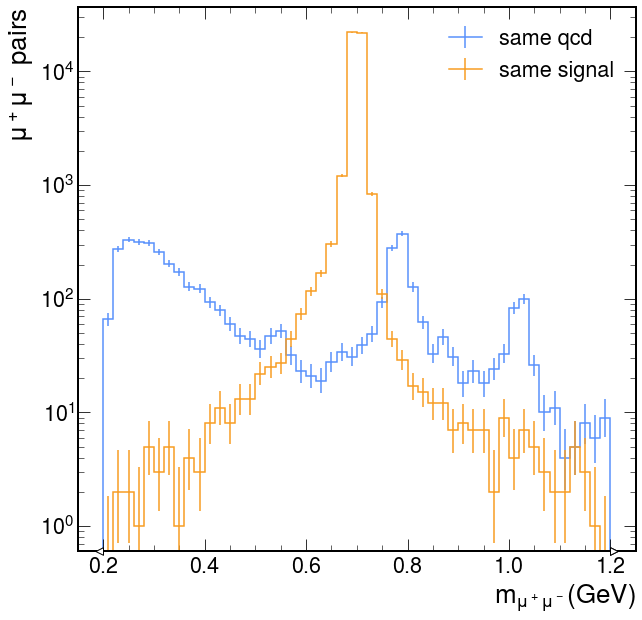

In [28]:
# h_same_qcd[::sum, :].plot(label="same qcd")
# h_same_signal[::sum, :].plot(label="same signal")
# plt.legend()
# plt.xlabel("$\Delta R$")
# plt.ylabel("$\mu^+\mu^-$ pairs")
# plt.xscale('log')
# # plt.yscale('log')
# plt.show()

h_same_qcd[:, ::sum].plot(label="same qcd")
h_same_signal[:, ::sum].plot(label="same signal")
plt.legend()
plt.xlabel("$m_{\mu^+\mu^-}$(GeV)")
plt.ylabel("$\mu^+\mu^-$ pairs")
# plt.xscale('log')
plt.yscale("log")
plt.show()